## Localization of Connexin Plaques in 3D Image

1. Function to detect and label all seperate regions in the binary 3D mask 
2. Function to create a properties table from 3D regions with: center of region (z, y, x), region size, mean intensity 
3. Analysis of the regions in voxel and micrometer 

In [1]:
# load packages 
from pathlib import Path
BASE_DIR = Path.cwd().parent
from skimage import io
import sys
sys.path.append(str(BASE_DIR / 'src'))
from localization import label_connexin_regions_3d, get_region_properties_3d
import matplotlib.pyplot as plt
import numpy as np


In [2]:
# load the 3D Sauvola segmentation and the deconvolved image (cropped to the 2_1 segmentation frame)
binary_sauvola_21_stack = io.imread(BASE_DIR / 'data/segmented/binary_sauvola2d_w21_k0_15.tiff')
preprocessed_image = io.imread(BASE_DIR / 'data/preprocessed/background_removed_and_deconvolved_img.tiff')
# match the 2_1 segmentation crop (z 60-500, x 23:999) so it aligns with the binary/labels
preprocessed_image = preprocessed_image[60:501, :, 23:999]

In [3]:
preprocessed_image.shape

(441, 2033, 976)

In [4]:
binary_sauvola_21_stack.shape

(441, 2033, 976)

#### 1. Function to detect and label all seperate regions in the binary 3D mask 
#### 2. Function to create a properties table from 3D regions with: center of region (z, y, x), region size, mean intensity 

In [5]:
%time labeled_3d, n_components = label_connexin_regions_3d(binary_sauvola_21_stack, connectivity=1)

Labeling connected regions in 3D...
  Connected regions found: 20019
CPU times: user 5.65 s, sys: 2.68 s, total: 8.33 s
Wall time: 8.37 s


In [6]:
%time locations = get_region_properties_3d(labeled_3d, preprocessed_image, spacing=(0.766, 0.325, 0.325))

  Regions summarized: 20019
CPU times: user 4.4 s, sys: 103 ms, total: 4.5 s
Wall time: 4.53 s


In [7]:
# Saving the results 
io.imsave(BASE_DIR / 'data/localization_binary_masks/brightest_region_label_mask.tiff', labeled_3d)
locations.to_csv(BASE_DIR / 'data/localization_binary_masks/region_properties.csv', index=False)

/home/rck292/cardiac_env/lib/python3.11/site-packages/skimage/_shared/utils.py:386: UserWarning: /home/rck292/Project/data/localization_binary_masks/brightest_region_label_mask.tiff is a low contrast image
  return func(*args, **kwargs)


In [8]:
locations.head()

,label,z,y,x,area_voxels,volume_um3,mean_intensity
0,1,31.791713,1864.936450,592.928611,3572.0,289.006055,7526.117676
1,2,14.000000,1859.000000,598.000000,1.0,0.080909,5741.953125
2,3,30.865994,1878.419669,612.522695,2776.0,224.602690,7421.486816
3,4,18.000000,1869.000000,616.000000,1.0,0.080909,6016.131836
4,5,32.904000,1899.998000,592.060000,1000.0,80.908750,7897.889160


### 3a Analysis for big image stack 

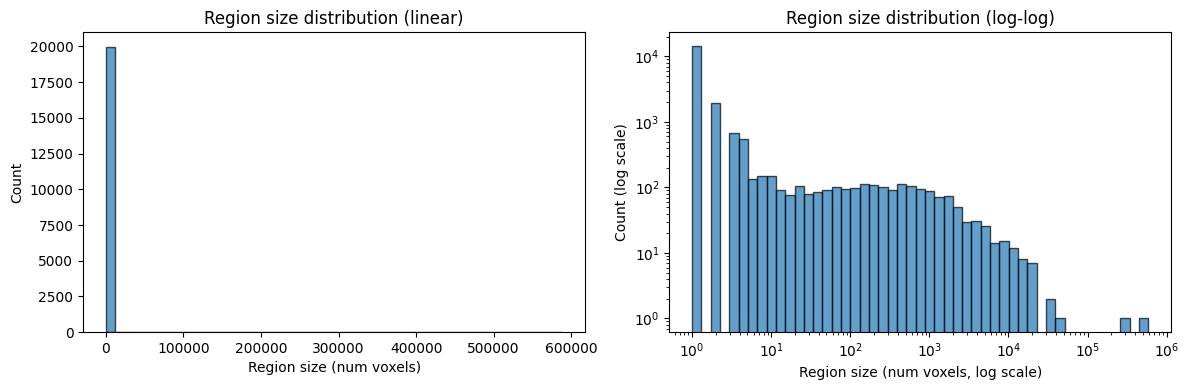

count     20019.000000
mean        137.676557
std        4822.529393
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max      588623.000000
Name: area_voxels, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Linear scale
axes[0].hist(locations['area_voxels'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Region size (num voxels)')
axes[0].set_ylabel('Count')
axes[0].set_title('Region size distribution (linear)')

# Log-log scale, to see the full range including any long tail
axes[1].hist(
    locations['area_voxels'],
    bins=np.logspace(0, np.log10(locations['area_voxels'].max()), 50),
    edgecolor='black', alpha=0.7
)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Region size (num voxels, log scale)')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Region size distribution (log-log)')

plt.tight_layout()
plt.show()

print(locations['area_voxels'].describe())

### 3. Analysis of the regions in voxel and micrometer 

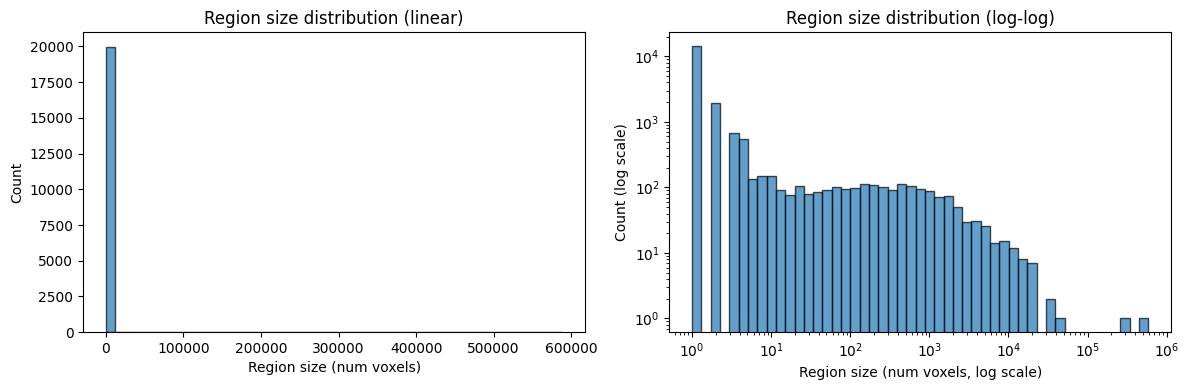

count     20019.000000
mean        137.676557
std        4822.529393
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max      588623.000000
Name: area_voxels, dtype: float64


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Linear scale
axes[0].hist(locations['area_voxels'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Region size (num voxels)')
axes[0].set_ylabel('Count')
axes[0].set_title('Region size distribution (linear)')

# Log-log scale, to see the full range including any long tail
axes[1].hist(
    locations['area_voxels'],
    bins=np.logspace(0, np.log10(locations['area_voxels'].max()), 50),
    edgecolor='black', alpha=0.7
)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Region size (num voxels, log scale)')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Region size distribution (log-log)')

plt.tight_layout()
plt.show()

print(locations['area_voxels'].describe())

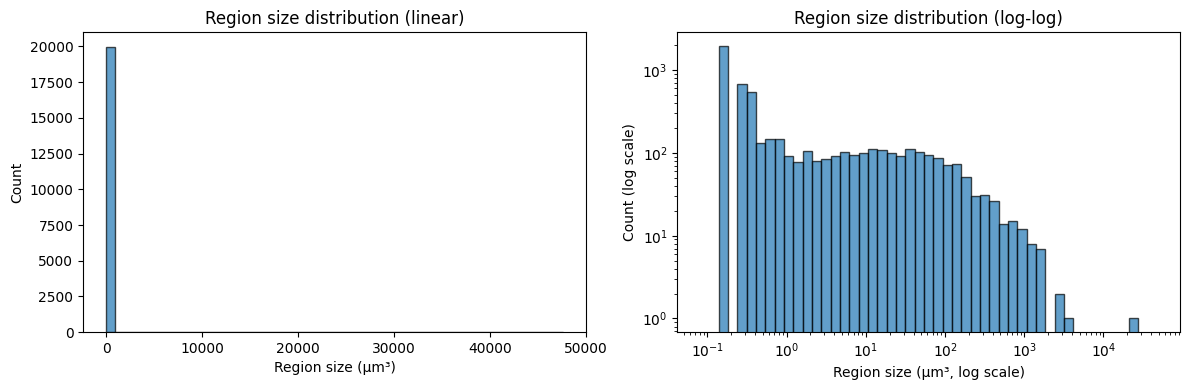

volume in µm³:
count    20019.000000
mean        11.139238
std        390.184825
min          0.080909
25%          0.080909
50%          0.080909
75%          0.161818
max      47624.751151
Name: volume_um3, dtype: float64
area in voxels:
count     20019.000000
mean        137.676557
std        4822.529393
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max      588623.000000
Name: area_voxels, dtype: float64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Linear scale
axes[0].hist(locations['volume_um3'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Region size (µm³)')
axes[0].set_ylabel('Count')
axes[0].set_title('Region size distribution (linear)')

# Log-log scale, to see the full range including any long tail
min_val = locations['volume_um3'].min()
max_val = locations['volume_um3'].max()
axes[1].hist(
    locations['volume_um3'],
    bins=np.logspace(np.log10(min_val), np.log10(max_val), 50),
    edgecolor='black', alpha=0.7
)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Region size (µm³, log scale)')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Region size distribution (log-log)')

plt.tight_layout()
plt.show()

print('volume in µm³:')
print(locations['volume_um3'].describe())
print('area in voxels:')
print(locations['area_voxels'].describe())  # keep for cross-reference against voxel counts